# **Project Name : PhonePe Transaction Insights**



# **Project Summary -**

**This project analyzes PhonePe Pulse data across multiple dimensions—transactions, insurance, and user behavior—using aggregated, district-level, and top-performing datasets. The data was cleaned, standardized, and explored through visualizations such as time series trends, category distributions, and geographic comparisons. The analysis highlights growth patterns over time, identifies dominant transaction types, evaluates regional performance, and examines user engagement. By combining these insights, the project uncovers key drivers of growth and areas with untapped potential.**

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Despite rapid growth in digital transactions, the business faces uneven adoption across services and regions—with heavy dependence on peer-to-peer payments, slower growth in insurance and financial services, and lower transaction volumes in several high-population but underpenetrated states. The challenge is to identify growth gaps and optimize strategies to drive balanced expansion across categories and geographies.**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [87]:
# Import Libraries

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Loading

In [88]:
# load datasets.

agg_transaction = pd.read_csv('/content/drive/MyDrive/Phonepe/agg_transaction.csv')
agg_insurance = pd.read_csv('/content/drive/MyDrive/Phonepe/agg_insurance.csv')
agg_user = pd.read_csv('/content/drive/MyDrive/Phonepe/agg_user.csv')

map_transaction = pd.read_csv('/content/drive/MyDrive/Phonepe/map_transaction.csv')
map_insurance = pd.read_csv('/content/drive/MyDrive/Phonepe/map_insurance.csv')
map_user = pd.read_csv('/content/drive/MyDrive/Phonepe/map_user.csv')

top_transaction = pd.read_csv('/content/drive/MyDrive/Phonepe/top_transaction.csv')
top_insurance = pd.read_csv('/content/drive/MyDrive/Phonepe/top_insurance.csv')
top_user = pd.read_csv('/content/drive/MyDrive/Phonepe/top_user.csv')

### Dataset First View

In [ ]:
# Dataset First Look

lst = [agg_transaction, agg_insurance, agg_user, map_transaction, map_insurance, map_user, top_transaction, top_insurance, top_user]
name = ['agg_transaction', 'agg_insurance', 'agg_user', 'map_transaction', 'map_insurance', 'map_user', 'top_transaction', 'top_insurance', 'top_user']
for i in range(len(lst)):
  print(name[i])
  print(lst[i].head())
  print(lst[i].shape, '\n')

agg_transaction
  state  year  quarter               entity_name       count        amount
0        2023        2         Merchant payments  8529595637  4.277821e+12
1        2023        2     Peer-to-peer payments  5374546962  1.772278e+13
2        2023        2  Recharge & bill payments  1190947064  9.047589e+11
3        2023        2        Financial Services     5195942  6.364034e+09
4        2023        2                    Others     9341245  6.919678e+09
(5174, 6) 

agg_insurance
  state  year  quarter entity_name    count        amount
0        2023        2   Insurance   893850  1.347400e+09
1        2023        3   Insurance  1010211  1.445235e+09
2        2023        4   Insurance  1159063  1.855300e+09
3        2023        1   Insurance   923173  1.408801e+09
4        2021        2   Insurance   363989  2.950667e+08
(701, 6) 

agg_user
  state  year  quarter    brand     count  percentage
0        2021        2   Xiaomi  75948492    0.248801
1        2021        2  Samsung 

### Dataset Information

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Dataset Info

for i in range(len(lst)):
  print(name[i])
  print(lst[i].info(), '\n')

agg_transaction
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5174 entries, 0 to 5173
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state        5034 non-null   object 
 1   year         5174 non-null   int64  
 2   quarter      5174 non-null   int64  
 3   entity_name  5174 non-null   object 
 4   count        5174 non-null   int64  
 5   amount       5174 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 242.7+ KB
None 

agg_insurance
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state        682 non-null    object 
 1   year         701 non-null    int64  
 2   quarter      701 non-null    int64  
 3   entity_name  701 non-null    object 
 4   count        701 non-null    int64  
 5   amount       701 non-null    float64
dtypes: float64(1

**Dataset Description :**

**Some common features :**
```
state : state in india.
year : Year in which transaction has occur.
quarter : Quarter in which trasaction has occur.
```

**In agg_transaction :**
```
entity_name : Type of transaction e.g. Peer-to-peer payments, Merchant payments, Recharge & bill payments.
count : total number of transactions
amount : total value of those transactions
```

**In agg_insurance :**
```
entity_name : Insurance category e.g. Health, Life, Motor.
count : Number of insurance purchesed
amount : total premium values.
```

**In agg_user :**
```
brad : Mobile brand used by users e.g. Xiaomi, Samsung, Apple.
count : Number of users using that brand
percentage : Share of that brand in total users (per state/quarter)
```

**In map_transaction :**
```
district : District name within state
count : Transacitons in that district
amount : Transaction value in that district
```

**In map_insurance :**
```
count : number of policies
amount : premium amount
```

**In map_user :**
```
registered_users : Total registered PhonePe users in that district
app_opens : Number of times the app was opened
```

**top_transaction and top_insurance :**
```
level : Granularity level (state, district, or pincode)
entity_name : Name of entity at that level (State name OR district OR pincode)
```

**top_user :**
```
registered_users : Number of users in that top entity
```

### What did you know about your dataset?

There are three major type tables and total nine sub tables.

Datasets contains transactional, insurance and user data.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Describe

for i in range(len(lst)):
  print(name[i])
  print(lst[i].describe(), '\n')

agg_transaction
              year      quarter         count        amount
count  5174.000000  5174.000000  5.174000e+03  5.174000e+03
mean   2021.002513     2.500773  9.094881e+07  1.335613e+11
std       1.999853     1.118142  6.254713e+08  1.002325e+12
min    2018.000000     1.000000  2.000000e+00  3.439721e+01
25%    2019.000000     2.000000  6.363575e+04  4.423959e+07
50%    2021.000000     3.000000  5.737635e+05  4.846731e+08
75%    2023.000000     4.000000  1.361543e+07  1.255325e+10
max    2024.000000     4.000000  1.741919e+10  2.663387e+13 

agg_insurance
              year     quarter         count        amount
count   701.000000  701.000000  7.010000e+02  7.010000e+02
mean   2022.111270    2.577746  4.141462e+04  5.710627e+07
std       1.370777    1.092188  1.397228e+05  2.085979e+08
min    2020.000000    1.000000  4.000000e+00  1.199000e+03
25%    2021.000000    2.000000  6.470000e+02  8.801820e+05
50%    2022.000000    3.000000  7.552000e+03  7.729792e+06
75%    2023.000

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# check null values

for i in range(len(lst)):
  print(name[i], " :")
  print(lst[i].isnull().sum(), '\n')

agg_transaction
state          0
year           0
quarter        0
entity_name    0
count          0
amount         0
dtype: int64 

agg_insurance
state          0
year           0
quarter        0
entity_name    0
count          0
amount         0
dtype: int64 

agg_user
state         0
year          0
quarter       0
brand         0
count         0
percentage    0
dtype: int64 

map_transaction
state       0
year        0
quarter     0
district    0
count       0
amount      0
dtype: int64 

map_insurance
state       0
year        0
quarter     0
district    0
count       0
amount      0
dtype: int64 

map_user
state               0
year                0
quarter             0
district            0
registered_users    0
app_opens           0
dtype: int64 

top_transaction
level          0
entity_name    2
state          0
year           0
quarter        0
count          0
amount         0
dtype: int64 

top_insurance
level          0
entity_name    3
state          0
year           0


Only top_transaction and top_insurance datasetes contain null values in 'entity_name' column.

In [89]:
# check the dataset where null value exist.

top_transaction[top_transaction['entity_name'].isnull()]

,level,entity_name,state,year,quarter,count,amount
10615,pincodes,NaN,ladakh,2019,4,2014,1.009866e+07
10665,pincodes,NaN,ladakh,2020,4,13717,3.671160e+07


null value occur at 'level' column is 'pincode' and where 'state' is 'ladakh'.

In [90]:
top_transaction[(top_transaction['state'] == 'ladakh') & (top_transaction['level'] == 'pincodes')]['entity_name'].mode()

,entity_name
0,194101
1,194102
2,194103
3,194104
4,194107
5,194201


I have checked the mode value of 'entity_name' feature where 'level' == 'pincode' and 'state' == 'ladakh'.

There are five modes so i will choose first one '194101'

In [91]:
# Replace null value with mode value.
top_transaction['entity_name'] = top_transaction['entity_name'].fillna('194101')

In [ ]:
# Now check null values for 'top_insurance' dataset.

top_insurance[top_insurance['entity_name'].isnull()]

,level,entity_name,state,year,quarter,count,amount
6996,pincodes,NaN,ladakh,2020,3,1,281.0
7006,pincodes,NaN,ladakh,2020,4,1,658.0
7087,pincodes,NaN,ladakh,2022,4,8,16020.0


This is same as 'top_transaction' dataset.

In [ ]:
top_insurance[(top_insurance['state'] == 'ladakh') & (top_insurance['level'] == 'pincodes')]['entity_name'].mode()

,entity_name
0,194101
1,194104


Again i will choose '194101' to full null value in 'entity_name'.

In [92]:
# Replace null value with mode value.
top_insurance['entity_name'] = top_insurance['entity_name'].fillna('194101')

Now all the datasets are non-null.

In [93]:
# Check duplicate values in each datasets.
print('Duplicate values in datasets.\n')
for i in range(len(lst)):
  print(name[i], ':', end = ' ')
  print(lst[i].duplicated().sum(), '\n')

Duplicate values in datasets.

agg_transaction : 0 

agg_insurance : 0 

agg_user : 0 

map_transaction : 0 

map_insurance : 0 

map_user : 0 

top_transaction : 0 

top_insurance : 0 

top_user : 0 



There is no duplicate values inside any dataset.

In [94]:
# make 'percentage' clean.
agg_user['percentage'] = agg_user['percentage'].apply(lambda x : round(x * 100, 2))
agg_user['percentage'].head()

,percentage
0,24.88
1,19.38
2,19.21
3,12.58
4,6.75


In [95]:
# Rename columns across all datasets (keeping 'count' and 'amount' unchanged)

# Aggregated tables
agg_transaction.rename(columns={
    "entity_name": "transaction_type"
}, inplace=True)

agg_insurance.rename(columns={
    "entity_name": "insurance_type"
}, inplace=True)

agg_user.rename(columns={
    "percentage": "user_percentage"
}, inplace=True)


# Map tables
map_user.rename(columns={
    "registered_users": "user_count",
    "app_opens": "app_opens_count"
}, inplace=True)


# Top tables
top_transaction.rename(columns={
    "entity_name": "entity"
}, inplace=True)

top_insurance.rename(columns={
    "entity_name": "entity"
}, inplace=True)

top_user.rename(columns={
    "entity_name": "entity",
    "registered_users": "user_count"
}, inplace=True)

### What all manipulations have you done and insights you found?

I have replace the null value in 'top_insurance' and 'top_transaction' datsets with the mode value.

And checked for dupliacate values but there is no duplicate values in any dataset.

Change some common columns name with appropriate name.

## ***4. Data Vizualization***

In [ ]:
def visulalize_trasaction_amount(df, title):
    df_grouped = df.groupby(['year', 'quarter']).agg({
        'amount': 'sum'
    }).reset_index()

    df_grouped = df_grouped.sort_values(by=['year', 'quarter'])
    df_grouped['time'] = df_grouped['year'].astype(str) + '-Q' + df_grouped['quarter'].astype(str)

    x = range(len(df_grouped))

    sns.lineplot(data = df_grouped, x = 'time', y = 'amount', label = 'amount')

    plt.xticks(x, df_grouped['time'], rotation=60)
    plt.title(title)
    plt.legend()

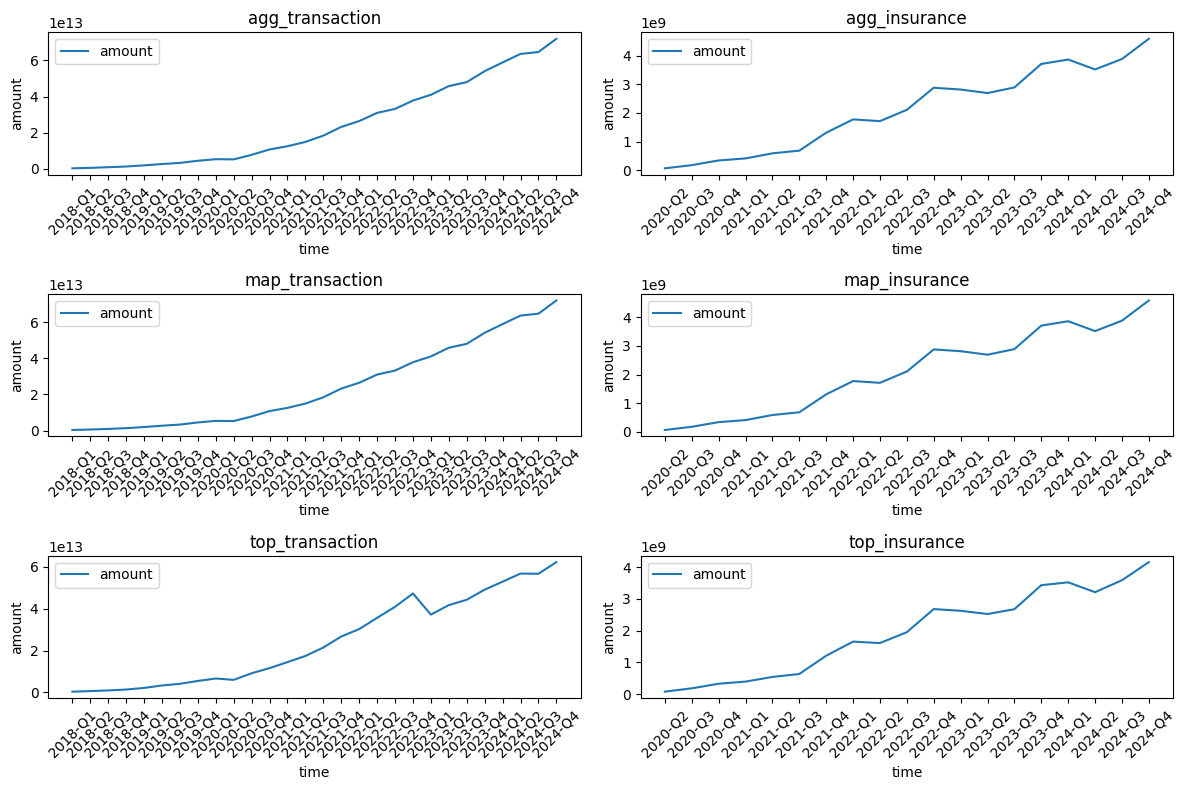

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(3, 2, 1)
visulalize_trasaction_amount(agg_transaction, 'agg_transaction')

plt.subplot(3, 2, 2)
visulalize_trasaction_amount(agg_insurance, 'agg_insurance')

plt.subplot(3, 2, 3)
visulalize_trasaction_amount(map_transaction, 'map_transaction')

plt.subplot(3, 2, 4)
visulalize_trasaction_amount(map_insurance, 'map_insurance')

plt.subplot(3, 2, 5)
visulalize_trasaction_amount(top_transaction, 'top_transaction')

plt.subplot(3, 2, 6)
visulalize_trasaction_amount(top_insurance, 'top_insurance')

plt.tight_layout()
plt.show()


The visualizations show a strong and consistent upward trend in transaction volumes from 2018 to 2024, indicating rapid adoption and near-maturity of digital payments, especially with accelerated growth after 2020 likely driven by increased UPI usage and pandemic-related digital shifts.

In contrast, insurance growth, while positive, is slower and exhibits minor fluctuations, suggesting it is still in a developing phase with significant untapped potential, and the similar patterns across aggregated, district, and top-level data confirm that this growth is widespread across regions rather than concentrated, highlighting deep market penetration into smaller cities and reinforcing that future business focus should shift toward expanding insurance adoption and sustaining engagement in an already mature payments ecosystem.

In [ ]:
def visulalize_trasaction_count(df, title):
    df_grouped = df.groupby(['year', 'quarter']).agg({
        'count': 'sum',
    }).reset_index()

    df_grouped = df_grouped.sort_values(by=['year', 'quarter'])
    df_grouped['time'] = df_grouped['year'].astype(str) + '-Q' + df_grouped['quarter'].astype(str)

    x = range(len(df_grouped))

    plt.bar(x, df_grouped['count'], label='Count')

    plt.xticks(x, df_grouped['time'], rotation=60)
    plt.title(title)
    plt.legend()

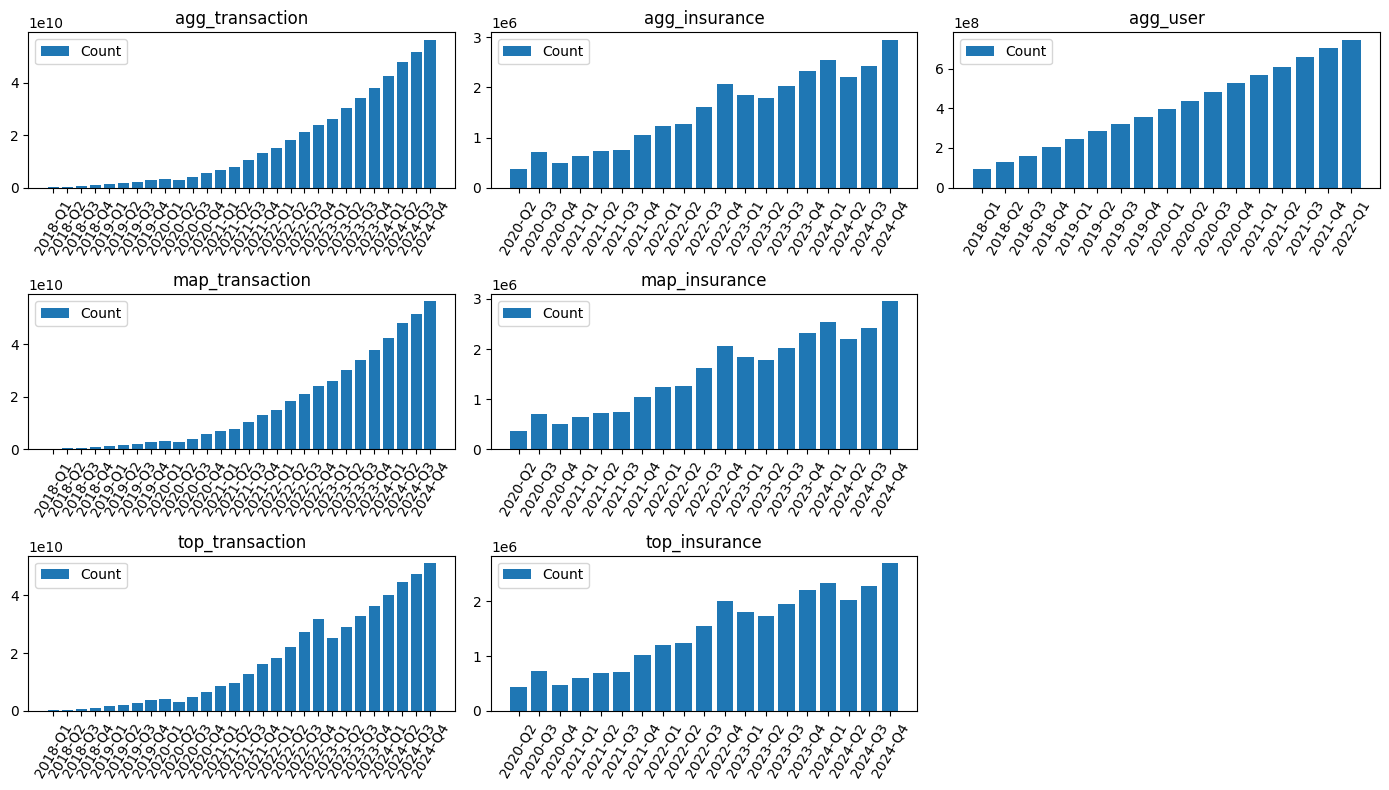

In [ ]:
plt.figure(figsize = (14, 8))

plt.subplot(3, 3, 1)
visulalize_trasaction_count(agg_transaction, 'agg_transaction')

plt.subplot(3, 3, 2)
visulalize_trasaction_count(agg_insurance, 'agg_insurance')

plt.subplot(3, 3, 3)
visulalize_trasaction_count(agg_user, 'agg_user')

plt.subplot(3, 3, 4)
visulalize_trasaction_count(map_transaction, 'map_transaction')

plt.subplot(3, 3, 5)
visulalize_trasaction_count(map_insurance, 'map_insurance')

plt.subplot(3, 3, 7)
visulalize_trasaction_count(top_transaction, 'top_transaction')

plt.subplot(3, 3, 8)
visulalize_trasaction_count(top_insurance, 'top_insurance')

plt.subplots_adjust(hspace = 0.6)
plt.tight_layout()
plt.show()

The charts show a strong and consistent increase in transaction counts from 2018 to 2024, indicating rapid user adoption and frequent usage of digital payments, while insurance counts are growing steadily but at a slower pace, highlighting that insurance is still in an early expansion phase compared to the highly mature payments ecosystem.

Additionally, the user growth trend aligns closely with transaction growth, suggesting that rising user base is directly driving transaction volume, and the similar patterns across aggregated, mapped, and top datasets confirm that this growth is widespread across regions, including deeper penetration into smaller districts, making it clear that while payments have reached high adoption levels, insurance remains a key opportunity for future business growth.

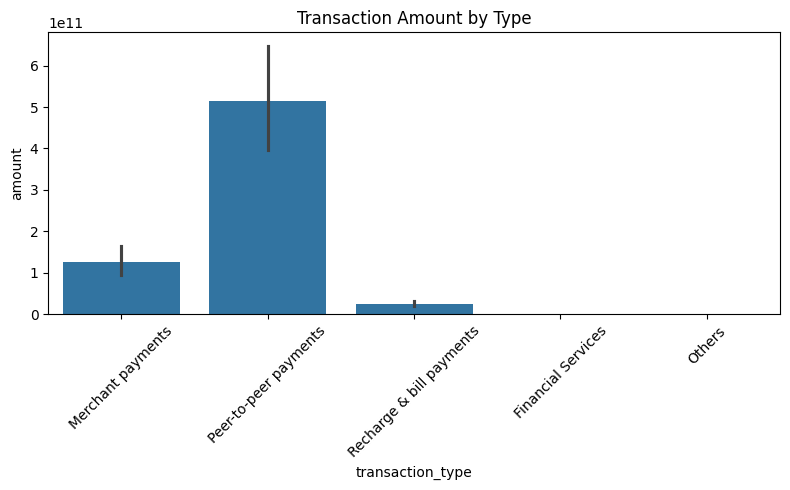

In [ ]:
# Transaction Type Distribution (agg_transaction)

plt.figure(figsize=(8,5))
sns.barplot(data=agg_transaction, x='transaction_type', y='amount')
plt.xticks(rotation=45)
plt.title("Transaction Amount by Type")
plt.tight_layout()
plt.show()

The chart shows that peer-to-peer (P2P) payments dominate transaction amount by a large margin, significantly outperforming merchant payments and other categories, which indicates that users primarily use the platform for direct money transfers rather than commercial transactions.

Merchant payments are the second-largest contributor, suggesting growing but still secondary adoption for business transactions, while recharge, bill payments, and financial services contribute relatively minimal amounts, highlighting an opportunity for the business to expand and promote these underutilized services to diversify revenue streams and reduce over-dependence on P2P transactions.

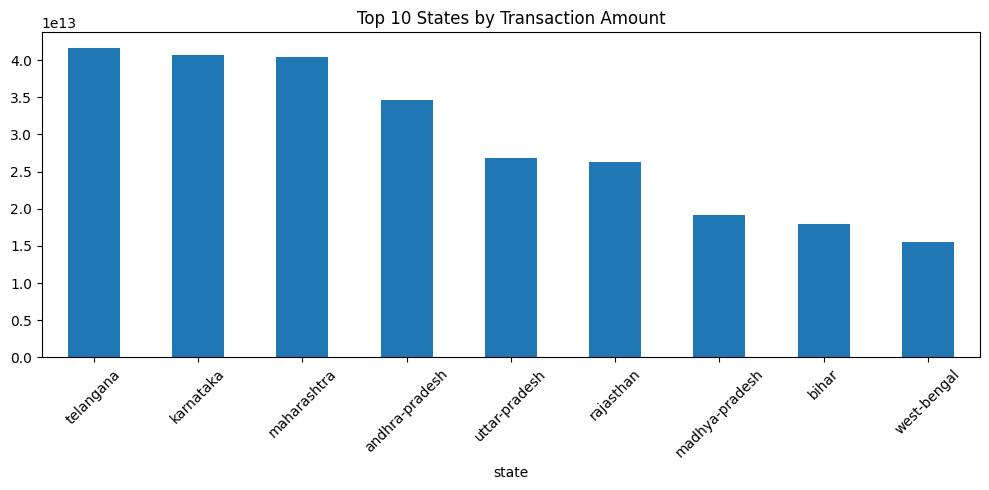

In [ ]:
# Insurance Category Analysis (agg_insurance)

state_txn = map_transaction.groupby('state')['amount'].sum().sort_values(ascending=False)[1:11]

plt.figure(figsize=(10,5))
state_txn.plot(kind='bar')
plt.title("Top 10 States by Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart indicates that Telangana, Karnataka, and Maharashtra lead in transaction amount, suggesting these states are the primary drivers of digital payment volume, likely due to higher urbanization, stronger digital infrastructure, and greater fintech adoption, while states like Uttar Pradesh, Rajasthan, Bihar, and West Bengal, despite large populations, contribute comparatively less, highlighting a significant growth opportunity in underpenetrated markets where increasing awareness, accessibility, and merchant adoption could substantially boost transaction volumes.

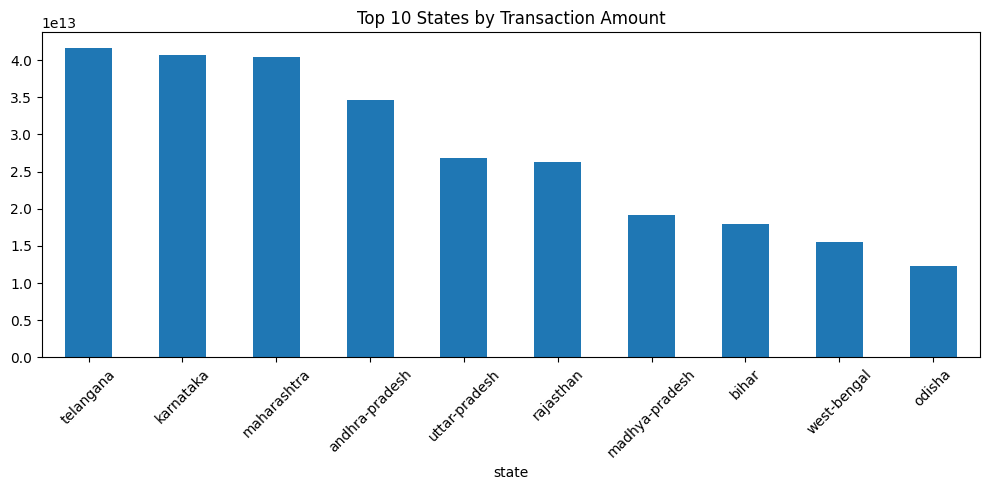

In [ ]:
# Top States by Transactions (map_transaction)

state_txn = map_transaction.groupby('state')['amount'].sum().sort_values(ascending=False)[1:11]

plt.figure(figsize=(10,5))
state_txn.plot(kind='bar')
plt.title("Top 10 States by Transaction Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows that Telangana, Karnataka, and Maharashtra are the top contributors to transaction value, indicating strong digital payment adoption driven by urbanization and robust fintech ecosystems, while states like Uttar Pradesh and Rajasthan have moderate contributions despite large populations, and states such as Bihar, West Bengal, and Odisha lag behind, highlighting a clear opportunity for expansion in less penetrated regions where increasing digital awareness, infrastructure, and merchant adoption could significantly boost transaction volumes.

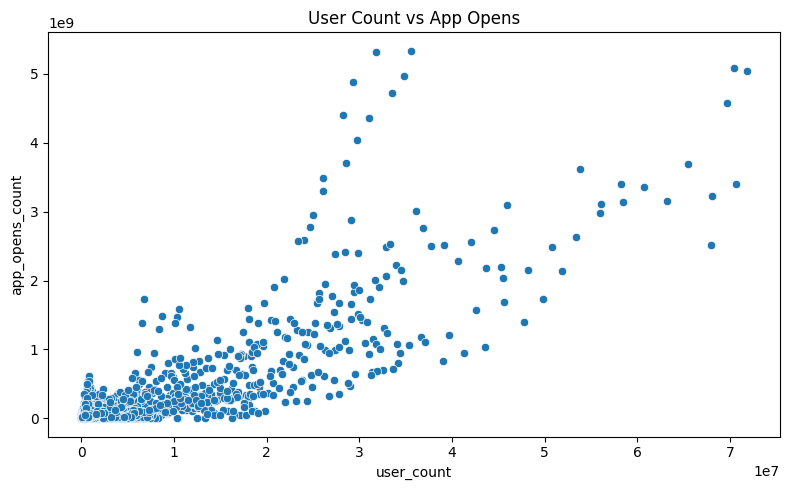

In [ ]:
# User Engagement (map_user)

plt.figure(figsize=(8,5))
sns.scatterplot(data=map_user, x='user_count', y='app_opens_count')
plt.title("User Count vs App Opens")
plt.tight_layout()
plt.show()

The scatter plot shows a clear positive relationship between user count and app opens, meaning that as your user base grows, total engagement (opens) generally increases; however, the spread widens significantly at higher user counts, indicating inconsistent engagement efficiency—some large user bases generate very high opens while others underperform, suggesting differences in retention, product experience, or user quality. This implies that growth alone isn’t enough.

The business should focus on improving engagement per user (e.g., through personalization, notifications, or feature optimization) and identifying what high-performing segments are doing differently, while also investigating outliers where high user counts don’t translate into proportional activity, as these represent missed revenue or retention opportunities.

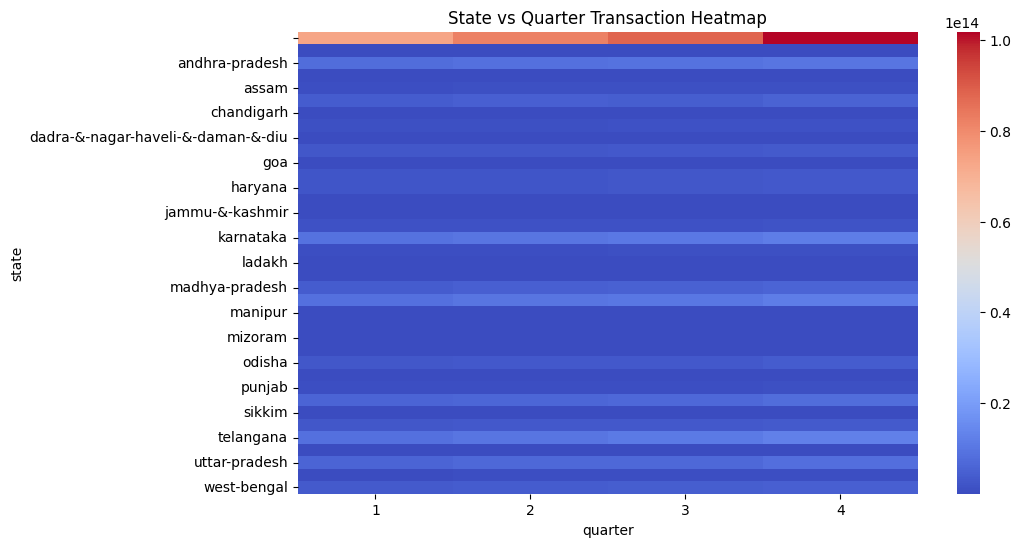

In [ ]:
# District-Level Heatmap (map_transaction)

pivot = map_transaction.pivot_table(values='amount', index='state', columns='quarter', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("State vs Quarter Transaction Heatmap")
plt.show()

The heatmap suggests that user engagement (likely app opens or activity) remains relatively stable across quarters for most states, but certain regions consistently show higher intensity, indicating stronger or more active user bases.

States like Karnataka, Andhra Pradesh, Madhya Pradesh, and Telangana appear to perform better across multiple quarters, pointing to reliable high-engagement markets that the business can prioritize for retention and monetization strategies, while states with lighter or flatter patterns may represent underpenetrated or low-engagement regions where targeted marketing, localization, or product adjustments could unlock growth; additionally, the lack of sharp seasonal variation across quarters implies that demand is steady rather than cyclical, so continuous engagement strategies may be more effective than seasonal campaigns.


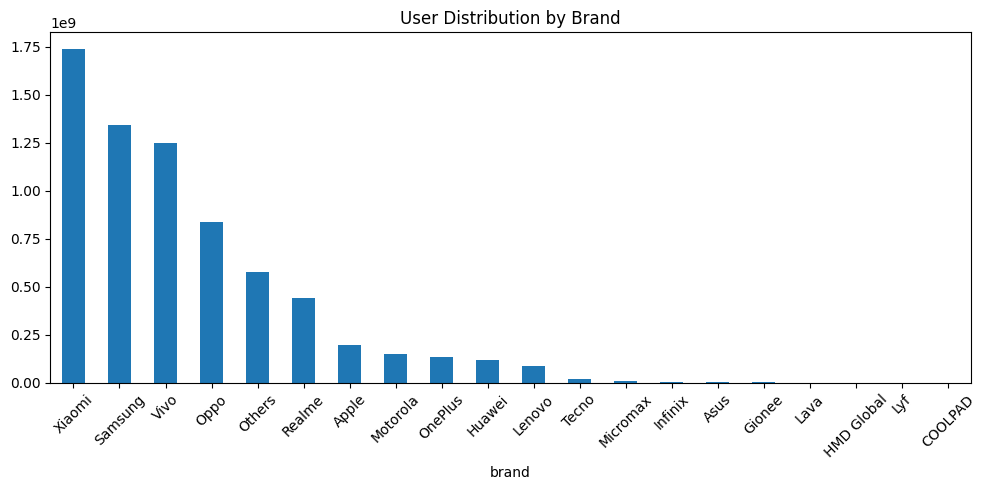

In [ ]:
# Brand Share (agg_user)

brand_df = agg_user.groupby('brand')['count'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
brand_df.plot(kind='bar')
plt.title("User Distribution by Brand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows a highly top-heavy smartphone market where Xiaomi leads significantly in user base, followed by strong but smaller positions from Samsung and Vivo, indicating intense competition among the top three. Mid-tier brands like Oppo and Realme maintain meaningful share but lag behind, while premium-focused Apple has a comparatively smaller user base, suggesting either a niche or higher-value segment strategy rather than volume leadership. The long tail of smaller brands (e.g., Motorola, OnePlus, Huawei) contributes marginally, highlighting market fragmentation beyond the leaders. Overall, the insight is that scale and pricing strategy are key drivers—dominant brands likely succeed through aggressive pricing and wide distribution, while smaller players must differentiate or target niche segments to compete effectively.


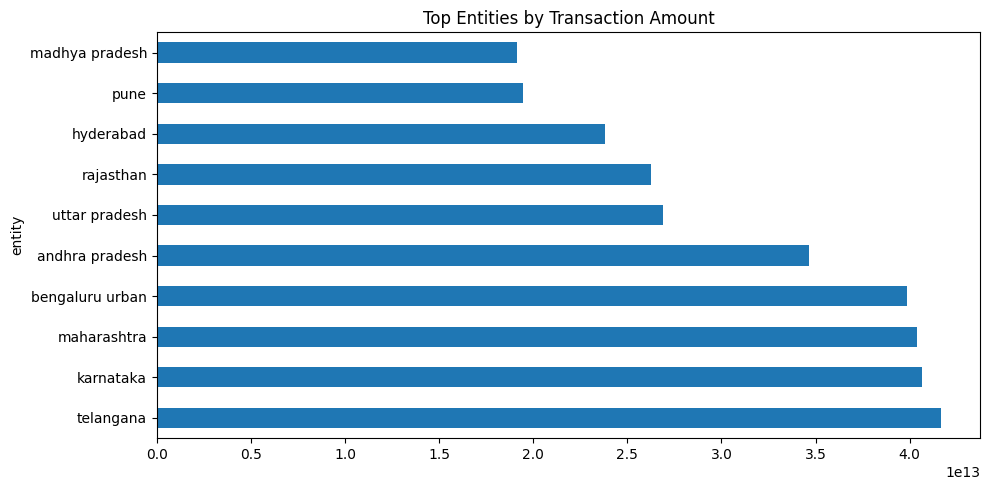

In [ ]:
# Top Performing Entities (top_transaction)

top_txn = top_transaction.groupby('entity')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_txn.plot(kind='barh')
plt.title("Top Entities by Transaction Amount")
plt.tight_layout()
plt.show()

The transaction data shows that Telangana, Karnataka, and Maharashtra dominate in total transaction value, with urban hubs like Bengaluru Urban contributing heavily—indicating that economically developed and tech-driven regions are key revenue engines. Mid-tier contributors such as Andhra Pradesh, Uttar Pradesh, and Rajasthan show strong but comparatively lower activity, suggesting growing adoption but possibly lower per-user spending.

Meanwhile, regions like Madhya Pradesh and cities like Pune lag behind, highlighting untapped potential. Overall, the key business insight is that focusing on high-performing urbanized states will maximize short-term revenue, while strategic expansion and targeted incentives in emerging regions could unlock significant future growth.

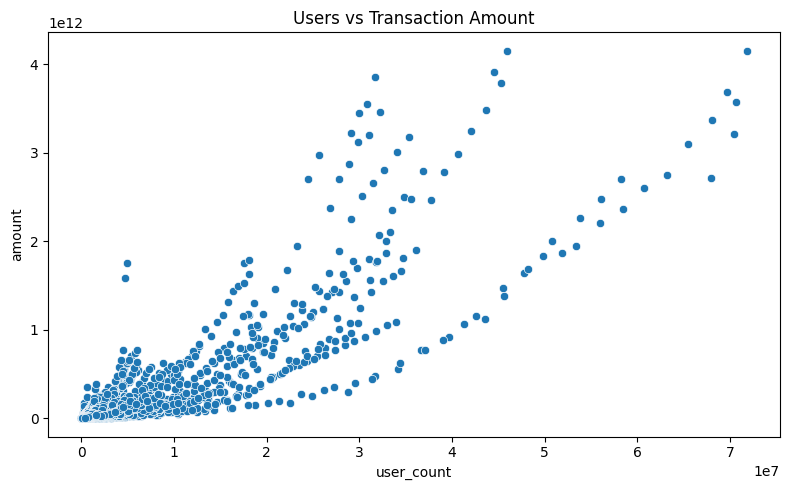

In [ ]:
# Transactions vs Users (Combined Insight)

merged = map_transaction.merge(
    map_user,
    on=['state', 'district', 'year', 'quarter'],
    how='inner'
)

plt.figure(figsize=(8,5))
sns.scatterplot(data=merged, x='user_count', y='amount')
plt.title("Users vs Transaction Amount")
plt.tight_layout()
plt.show()

The scatter plot reveals a clear positive correlation between user count and transaction amount, meaning regions or segments with more users tend to generate higher total transaction value; however, the wide dispersion indicates that user volume alone doesn’t fully explain revenue, as some clusters achieve disproportionately higher transaction amounts at similar user levels. This suggests that factors like user engagement, transaction frequency, and average ticket size play a critical role—highlighting that simply acquiring users isn’t enough; businesses should focus on improving per-user monetization and driving higher-value transactions in addition to scaling their user base.


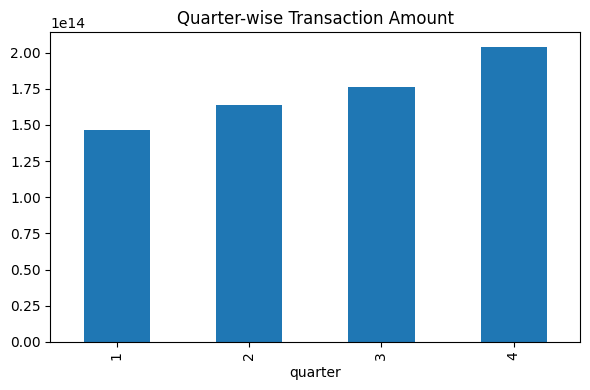

In [ ]:
# Quarterly Growth Comparison

quarterly = agg_transaction.groupby('quarter')['amount'].sum()

plt.figure(figsize=(6,4))
quarterly.plot(kind='bar')
plt.title("Quarter-wise Transaction Amount")
plt.tight_layout()
plt.show()

The chart shows a clear upward trend in transaction amounts across the four quarters, indicating consistent business growth throughout the year. Starting from roughly 1.46×10¹⁴ in Q1, transactions steadily increase each quarter, reaching about 2.05×10¹⁴ in Q4, which is the highest point. This suggests strengthening customer activity or higher sales volume over time, with particularly strong performance in the final quarter—potentially driven by seasonal demand, successful marketing efforts, or expanded operations. Overall, the pattern reflects positive momentum and effective scaling of the business.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

To achieve the business objective, the client should focus on **expanding beyond its current strengths and unlocking underutilized segments**. Since transactions—especially peer-to-peer—are already highly mature, the priority should be to **diversify revenue streams by promoting merchant payments, insurance, and financial services**, where adoption is still relatively low. At the same time, the client should **target underpenetrated states (e.g., Bihar, Odisha, West Bengal)** through localized campaigns, incentives, and improved digital infrastructure to drive user acquisition and transaction growth. Enhancing **user engagement** via personalized offers, cashback, and seamless user experience will help convert growing user base into higher transaction frequency. Additionally, leveraging data for **targeted marketing and cross-selling (e.g., offering insurance to active users)** can significantly boost monetization, ensuring sustained growth rather than reliance on already saturated segments.

# **Conclusion**

**The analysis reveals that digital payments have reached a mature and high-growth stage, driven primarily by peer-to-peer transactions and increasing user adoption, while insurance and financial services remain underutilized but present strong future opportunities. Growth is widespread across regions but still concentrated in a few leading states, indicating significant scope for expansion in underpenetrated markets. To sustain long-term growth, the business must diversify beyond P2P transactions, strengthen presence in emerging regions, and enhance user engagement through targeted strategies, ensuring a more balanced and scalable ecosystem.**